<a href="https://colab.research.google.com/github/enriquefroes/futebol-dinheiro-e-desempenho/blob/main/notebooks/04_patrocinio_por_ponto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_futebol'
except ImportError:
    BASE = './analise_futebol'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (DADOS, GRAF, TAB):
    os.makedirs(p, exist_ok=True)

ARQUIVO = os.path.join(DADOS, 'clubes_2026.csv')
if not os.path.exists(ARQUIVO):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb para criar o CSV no Drive.')
df = pd.read_csv(ARQUIVO)

MESES_DECORRIDOS = 9
df['pontos_por_jogo'] = df['pontos'] / df['jogos']
df['gasto_transferencias'] = df['gasto_janela1'].fillna(0) + df['gasto_janela2'].fillna(0)
df['folha_anual'] = df['folha_mensal'] * 13
df['folha_ate_agora'] = df['folha_mensal'] * MESES_DECORRIDOS

def rotular(ax, dados, x, y, ajustes=None):
    """Escreve o nome do clube ao lado de cada ponto; 'ajustes' desloca rótulos sobrepostos."""
    ajustes = ajustes or {}
    for _, r in dados.iterrows():
        ax.annotate(r['time'], (r[x], r[y]), xytext=ajustes.get(r['time'], (6, 4)),
                    textcoords='offset points', fontsize=9)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150)
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
d = df.dropna(subset=['patrocinio_bet_anual']).copy()
d['patrocinio_ate_agora'] = d['patrocinio_bet_anual'] * MESES_DECORRIDOS / 12
d['patrocinio_por_ponto'] = d['patrocinio_ate_agora'] / d['pontos']

tabela = (d[['time', 'patrocinador_bet', 'patrocinio_bet_anual', 'patrocinio_ate_agora', 'pontos', 'patrocinio_por_ponto']]
          .sort_values('patrocinio_por_ponto', ascending=False).round(2))
tabela.to_csv(os.path.join(TAB, '04_patrocinio_por_ponto.csv'), index=False)
print('Correlação patrocínio x pontos por jogo:', round(d['patrocinio_bet_anual'].corr(d['pontos_por_jogo']), 2))
tabela

Correlação patrocínio x pontos por jogo: 0.63


,time,patrocinador_bet,patrocinio_bet_anual,patrocinio_ate_agora,pontos,patrocinio_por_ponto
13,Corinthians,Esportes da Sorte,150.0,112.50,32,3.52
0,Flamengo,Betano,268.5,201.38,60,3.36
10,São Paulo,Superbet,95.0,71.25,36,1.98
1,Palmeiras,Sportingbet,100.0,75.00,57,1.32
11,Botafogo,VBet,55.0,41.25,35,1.18
6,Atlético-MG,H2Bet,60.0,45.00,40,1.12
3,Fluminense,Superbet,52.0,39.00,48,0.81
5,Cruzeiro,Betnacional,42.0,31.50,45,0.70
7,Santos,Novibet,35.0,26.25,38,0.69
19,Chapecoense,Zeroum Bet,15.0,11.25,18,0.62


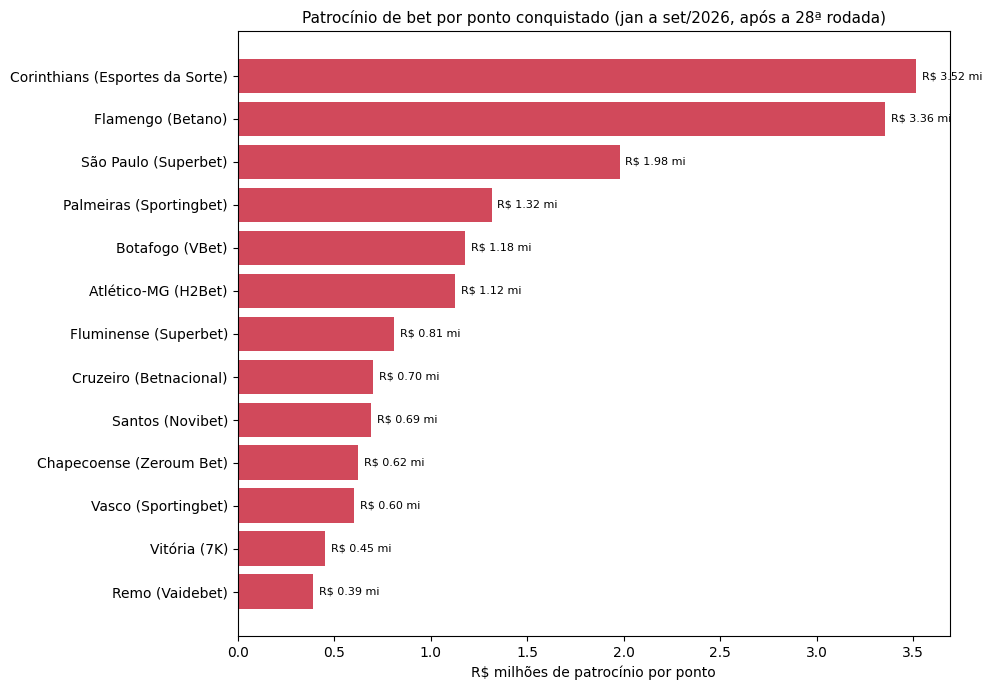

Salvo em /content/drive/MyDrive/analise_futebol/graficos/04a_patrocinio_por_ponto.png


In [3]:
t = d.sort_values('patrocinio_por_ponto')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(t['time'] + ' (' + t['patrocinador_bet'] + ')', t['patrocinio_por_ponto'], color='#d1495b')
for i, v in enumerate(t['patrocinio_por_ponto']):
    ax.text(v + 0.03, i, f'R$ {v:.2f} mi', va='center', fontsize=8)
ax.set_title(f'Patrocínio de bet por ponto conquistado (jan a set/2026, após a 28ª rodada)', fontsize=11)
ax.set_xlabel('R$ milhões de patrocínio por ponto')
salvar('04a_patrocinio_por_ponto.png')

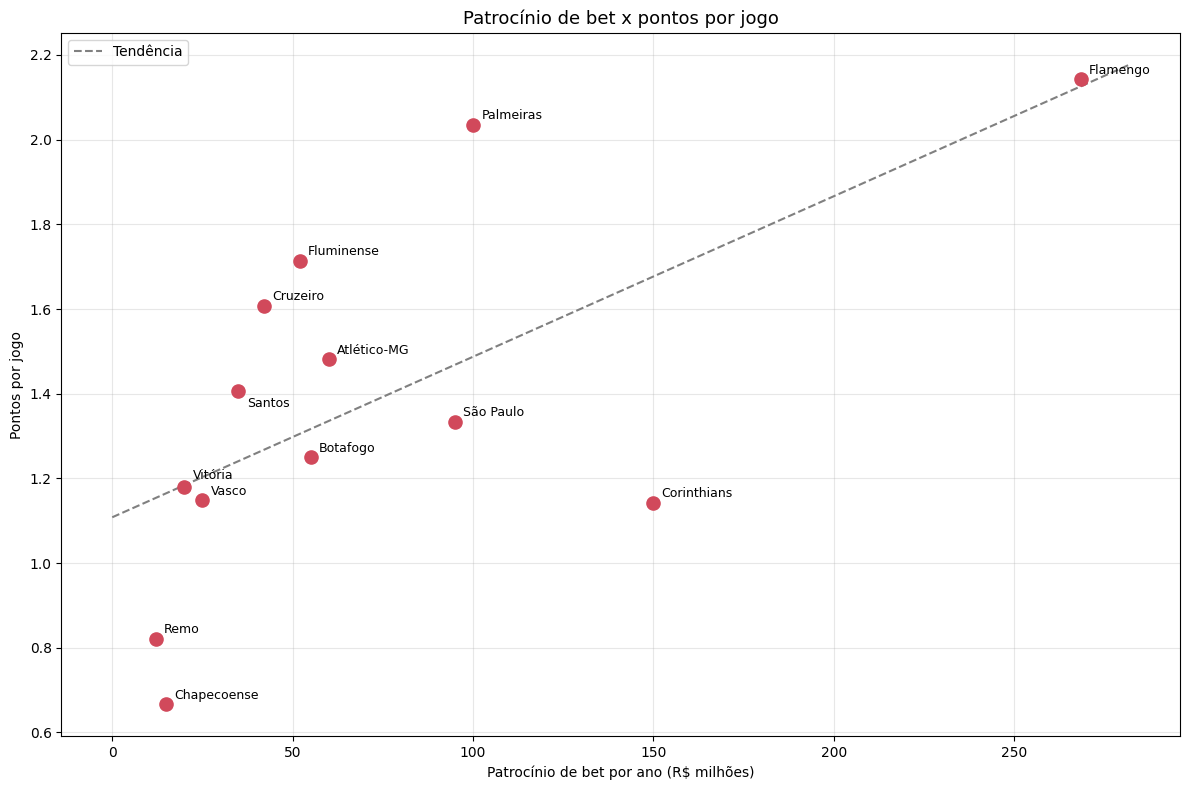

Salvo em /content/drive/MyDrive/analise_futebol/graficos/04b_patrocinio_x_pontos.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(d['patrocinio_bet_anual'], d['pontos_por_jogo'], s=90, color='#d1495b', zorder=3)
coef = np.polyfit(d['patrocinio_bet_anual'], d['pontos_por_jogo'], 1)
xs = np.linspace(0, d['patrocinio_bet_anual'].max() * 1.05, 100)
ax.plot(xs, np.polyval(coef, xs), '--', color='gray', label='Tendência')
rotular(ax, d, 'patrocinio_bet_anual', 'pontos_por_jogo', {'Santos': (6, -12), 'Vitória': (6, 6)})
ax.set_title('Patrocínio de bet x pontos por jogo', fontsize=13)
ax.set_xlabel('Patrocínio de bet por ano (R$ milhões)')
ax.set_ylabel('Pontos por jogo')
ax.grid(alpha=0.3); ax.legend(loc='upper left')
salvar('04b_patrocinio_x_pontos.png')